## 1. The research question

**Does self-organized homophily make misinformation more contagious?**

An agent-based simulation combining homophilic network rewiring with a misinformation-fact-checking spreading process.

In other words: when individuals in a social network are allowed to rewire their own ties toward similar others (instead of being placed in a fixed, pre-segregated network), does a piece of misinformation reach a larger fraction of the population?

The question is answerable with a number: The final share of believers, $p^B(\infty)$, as a function of how strongly people prefer to connect with similar others, and with a **yes/no** verdict comparing the homophilic case against a non-homophilic baseline.

### Key terms

- **Self-organized homophily**: clusters of like-minded individuals that emerge *endogenously* through local rewiring decisions, rather than being hard-coded into the network from the start. The contrast is with Törnberg (2018), where echo chambers are placed into the network as a fixed structural feature.
- **Misinformation**: a piece of low-credibility content competing with its own debunking ("fact-checking"), modeled following Tambuscio et al. (2015).
- **Contagious**: measured by the equilibrium fraction of nodes in the
Believer state at the end of the simulation.

### Why this question is relevant

The viral spread of digital misinformation is now considered one of the principal risks to modern societies (Howell, 2013; cited in Törnberg, 2018). Two large bodies of work address it from different angles:

- The homophily literature (McPherson, Smith-Lovin & Cook, 2001; Smirnov & Thurner, 2017) studies why social networks become segregated.
- The misinformation-spreading literature (Tambuscio et al., 2015; Mazzoli et al., 2018; Sulis & Tambuscio, 2020; Törnberg, 2018) studies how false content propagates once a network exists.

These two strands rarely meet in a fully coupled model. We bring them together by letting the network and the spreading process co-evolve, which is closer to what happens on real platforms where users continuously add and drop ties while content is circulating.

## 3. Theoretical background, literature gap, and hypotheses

### 3.1 Homophily as an organizing principle

McPherson, Smith-Lovin & Cook (2001) define in the canonical review "Birds of a Feather" homophily as the principle that contact between similar people occurs at a higher rate than among dissimilar people. The consequence is that anything flowing through a network (information, behaviors, beliefs) tends to remain localized in social space.

They distinguish two analytically important variants:

- **Baseline homophily** is similarity that comes simply from the composition of the available pool of contacts. If 90% of the people you can possibly meet share some trait, you will share it with most of your contacts even without any preference.
- **Inbreeding homophily** is similarity over and above this baseline, actual preference driven, structurally induced, or socially reinforced excess.

For our project the important takeaway is that homophily is pervasive across many tie types (friendship, marriage, advice, discussion) and many dimensions (race, age, education, beliefs). It is a near universal feature of human social networks and therefore a realistic ingredient for a model of online interaction.

### 3.2 How homophily forms: selection vs. socialization

Smirnov & Thurner (2017) ask the dynamical question: how does homophily form over time in an initially homogeneous population? They identify two mechanisms:

- **Socialization (peer influence)**: individuals change their traits to match those of their static social environment. The network is fixed; the nodes change.
- **Selection**: individuals change their network by rewiring ties toward more similar others. The traits are fixed; the edges change.

Using a longitudinal dataset of around 6,000 Russian high-school and university students over 42 months, combining VK "like" interactions (as a friendship proxy) with academic GPA records, they find that homophily in academic performance roughly doubles over time. They quantify this with the Homophily Index $H(t)$, defined as the Pearson correlation between a student's GPA and the average GPA of their direct friends (Smirnov & Thurner 2017, p. 11, Eq. 1):

$$H(t) = \mathrm{corr}\!\left(G_i(t),\ \frac{\sum_j A_{ij}(t)\, G_j(t)}{\sum_j A_{ij}(t)}\right)$$

where $G_i(t)$ is the GPA of student $i$ at time $t$ and $A_{ij}(t)$ is the adjacency matrix at time $t$. In their data $H$ grows from around 0.20 to around 0.41 over the observation period (Smirnov & Thurner 2017, p. 7). Their headline result: this increase is driven almost entirely by selection. Students do not adjust their grades to their friends; they swap friends to match their grades.

Their minimal rewiring model (Smirnov & Thurner 2017, p. 9) is the direct inspiration for our network dynamic:

Pick a student $i$, pick a current friend $j$, pick a potential new friend $k$.
If $|G_i - G_k| \leq |G_i - G_j|$, rewire the link from $ij$ to $ik$.
Otherwise, rewire from $ij$ to $ik$ anyway, with probability $\theta$.

The single parameter $\theta \in [0, 1]$ controls the rewiring regime:
- $\theta = 0$ -> strict homophily (only ever move to a more similar friend).
- $\theta = 1$ -> pure random rewiring (no homophilic preference at all).

Fitted to their empirical data, Smirnov & Thurner obtain $\theta \approx 0.55$-$0.61$ (p. 9), meaning students choose a more similar new friend 64%-81% more often than chance.

This $\theta$ will be the central knob in our experiment.

### 3.3 Misinformation as complex contagion

Tambuscio et al. (2015) propose the SBFC model, a compartmental epidemic-style model that simulates a hoax and its debunking spreading simultaneously over the same network. Following their notation (Tambuscio et al. 2015, p. 978), every agent $i$ is at time $t$ in exactly one of three states:

| State | Meaning |
|---|---|
| **S** — Susceptible | Has not engaged with the news yet / neutral. |
| **B** — Believer | Currently believes and spreads the hoax. |
| **F** — Fact-Checker | Has verified the news and spreads the correction. |

The dynamics are governed by four parameters (Tambuscio et al. 2015, p. 978):

| Parameter | Interpretation |
|---|---|
| $\beta \in [0, 1]$ | Spreading rate (how often content reaches a neighbor). |
| $\alpha \in [0, 1)$ | Credibility / gullibility: Gives the hoax a relative advantage over its debunking. |
| $p_{\text{verify}}$ | Probability per step that a Believer fact-checks and switches to F. |
| $p_{\text{forget}}$ | Probability per step that any B or F forgets and returns to S. |

The transitions for an agent $i$ depend on the states of its current neighbors. The "spreading functions" $f_i$ (S -> B) and $g_i$ (S -> F) are defined as (Tambuscio et al. 2015, p. 978, Eq. 5):

$$f_i(t) = \beta \, \frac{n_i^B(t)\,(1+\alpha)}{n_i^B(t)\,(1+\alpha) + n_i^F(t)\,(1-\alpha)}$$

$$g_i(t) = \beta \, \frac{n_i^F(t)\,(1-\alpha)}{n_i^B(t)\,(1+\alpha) + n_i^F(t)\,(1-\alpha)}$$

where $n_i^B(t)$ and $n_i^F(t)$ are the counts of Believer and Fact-Checker neighbors of agent $i$ at time $t$. The key feature: An agent's probability of becoming a Believer grows with the number of Believer neighbors, capturing the idea of complex contagion: The more people around you adopt a view, the more convincing it becomes (Centola & Macy 2007, discussed in Törnberg 2018, p. 4).

From a mean-field analysis (Tambuscio et al. 2015, Appendix A, pp. 981-982), they derive a central analytical eradication threshold (Tambuscio et al. 2015, p. 980, Eq. 9):

$$p_{\text{verify}} \geq \frac{2\alpha}{1 - \alpha}\, p_{\text{forget}} \quad \rightarrow \quad p^B(\infty) = 0$$

In words: if fact-checking is fast enough relative to forgetting (scaled by gullibility), the hoax dies out completely in the long run, i.e. the steady-state believer fraction $p^B(\infty)$ goes to zero.

Importantly, this threshold was derived for static networks. Whether it still holds when the network itself is rewiring homophilically is one of the things our experiment can investigate.

Sulis & Tambuscio (2020) later re-implemented the same SBFC model in NetLogo, confirming the dynamics in a fully agent-based setting, which is exactly the implementation route we will take in Mesa.

Mazzoli et al. (2018) take a related but distinct route: they simulate a real Twitter event (the Higgs-boson announcement, and an Occupy Wall Street hoax) using individual gullibility thresholds and three spreading channels (spontaneous, collective, persuasive). Importantly for us, they observe that echo chambers emerge as a side-effect of the spreading process, even without any explicit network restructuring. This hints that the link between segregation and misinformation runs both ways.

### 3.4 The echo-chamber effect

Törnberg (2018) is the most direct precedent for our question. He shows in a network simulation that an echo chamber, defined by two properties (Törnberg 2018, p. 3):

- **opinion polarization** $P_o$: cluster members have a lower activation threshold for the contagion,
- **network polarization** $P_n$: cluster members are more densely connected to each other than to outsiders

acts as a launchpad for viral cascades of complex contagions. The polarized cluster provides the local critical mass (a "bandwagon") that the contagion needs to escape into the rest of the network through weak ties. He quantifies the outcome as the virality $V(\theta, P_n, P_o)$, the fraction of simulation runs in which a majority of nodes ends up activated (Törnberg 2018, p. 5).

He further reports a synergistic effect: combining opinion polarization with network polarization produces more virality than the sum of the two effects in isolation (Törnberg 2018, p. 10, Fig. 6). Virality peaks at intermediate network polarization $P_n \approx 0.6$ (Törnberg 2018, p. 7, Fig. 1).

The crucial limitation in Törnberg's design: the echo chamber is hand-built into the network at $t = 0$ and stays fixed throughout the simulation. The network does not evolve.

### 3.5 The literature gap we address

Stacking the four spreading papers and the two homophily papers side by side, a clear gap appears:

| Paper | Network dynamic | Spreading dynamic |
|---|---|---|
| McPherson et al. (2001) | (review of patterns) | - |
| Smirnov & Thurner (2017) | rewiring by selection | - |
| Tambuscio et al. (2015) | static | SBFC |
| Sulis & Tambuscio (2020) | static | SBFC in NetLogo |
| Mazzoli et al. (2018) | static BA graph | threshold + persuasion |
| Törnberg (2018) | pre-built echo chamber | complex contagion |

No paper lets the network co-evolve homophilically while a misinformation process is running on it.

Törnberg himself flags this in his conclusion: more work is needed to test whether his findings hold in real, changing networks. Our project fills exactly this gap by coupling Smirnov & Thurner's rewiring rule with Tambuscio et al.'s SBFC spreading process in a single co-evolving agent-based model.

### 3.6 Hypotheses

We pre-register the following expectations, derived from the literature above:

**H1: Main effect**

Lower values of $\theta$ (stronger homophilic rewiring) lead to a higher final believer fraction $p^B(\infty)$, holding the spreading parameters constant.

Why we expect this: Törnberg (2018) shows that pre-built echo chambers boost virality of complex contagions; if echo chambers form endogenously through low-$\theta$ rewiring, the same effect should appear.

**H2: Threshold shift**

The Tambuscio eradication threshold $p_{\text{verify}} \geq \frac{2\alpha}{1-\alpha} p_{\text{forget}}$ underestimates the fact-checking effort needed when the network is allowed to rewire homophilically.

Why we expect this: The threshold was derived for static, well-mixed networks. Self-organized clusters protect believers from contact with fact-checkers.

**H3: Non-linear sensitivity**

$p^B(\infty)$ does not respond linearly to $\theta$; we expect a sharp transition zone around intermediate $\theta$ values (consistent with Törnberg's finding that virality peaks at intermediate, not maximal, network polarization).

If H1 and H2 both fail, the answer to our research question is No, self-organized homophily does not make misinformation more contagious, and that would itself be a meaningful, publishable null result.

## A: Setup

We install Mesa 3.5.x together with the scientific stack and fix a single
global random seed so that every figure in this notebook is reproducible.


In [ ]:
%pip install "mesa[rec]" networkx numpy matplotlib pandas tqdm

In [ ]:
import numpy as np
import pandas as pd
import mesa
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# One global seed
GLOBAL_SEED = 6767
np.random.seed(GLOBAL_SEED)

## B: Agent and Model classes

We implement the two source mechanisms in one co-evolving agent-based model:

- **`MisinfoAgent`** carries a static continuous trait (the homophily
  dimension, analogous to GPA in Smirnov & Thurner 2017) and a dynamic SBFC
  state $\in \{S, B, F\}$ (Tambuscio et al. 2015). Its two behaviours are
  rewire_step() (selection rewiring) and spread_step() (SBFC transition).
- **`HomophilyMisinfoModel`** holds the rewiring network, all parameters and a
  DataCollector. Each step() rewires ties, then spreads, then records.

Modelling choice, how the two layers are coupled: Smirnov & Thurner rewire
on a fixed trait, while Tambuscio's belief is dynamic. To link them we seed
the initial believers in the high-trait tail, so that strong homophilic
rewiring (low $\theta$) pulls believers together into an endogenous echo
chamber. This is the mechanism H1 is about, it is a deliberate choice you can
revisit (e.g. seed at random, or rewire on state instead of trait).

In [ ]:
class MisinfoAgent(mesa.Agent):
    """One individual in social network.
    trait : float in [0,1] static homophily dimension (Smirnov & Thurner 2017).
    state : "S" "B" "F" dynamic SBFC state (Tambuscio et al. 2015).
    """

    def __init__(self, model, trait):
        super().__init__(model)
        self.trait = trait                 # fixed for the whole run
        self.state = "S"                   # everyone starts Susceptible
        self._next_state = "S"             # buffer for synchronous SBFC update

    def neighbors(self):
        # Agents adjacent in the current (rewiring) graph.
        return [self.model.node_to_agent[n]
                for n in self.model.G.neighbors(self.unique_id)]

    def rewire_step(self):
      """Smirnov & Thurner (2017) selection rewiring, one attempt per step."""
      G = self.model.G
      rng = self.model.rng
      i = self.unique_id

      current_friends = list(G.neighbors(i))
      if not current_friends:
          return
      # pick one existing tie to potentially drop
      friend = current_friends[rng.integers(len(current_friends))]

      # all agents i is not yet connected to (and not itself)
      possible_new = [n for n in self.model.node_ids
                      if n != i and not G.has_edge(i, n)]
      if not possible_new:
          return
      # pick one candidate to potentially connect to
      candidate = possible_new[rng.integers(len(possible_new))]

      # trait distance (0 = identical, 1 = maximally different)
      dist_to_candidate = abs(self.trait - self.model.node_to_agent[candidate].trait)
      dist_to_friend    = abs(self.trait - self.model.node_to_agent[friend].trait)

      # move the tie if the candidate is at least as similar as the current
      # friend, or otherwise with probability theta (random rewiring)
      if dist_to_candidate <= dist_to_friend or rng.random() < self.model.theta:
          G.remove_edge(i, friend)
          G.add_edge(i, candidate)

    def spread_step(self):
        """Tambuscio et al. (2015) SBFC transition, computes the NEXT state.

        S->B / S->F via spreading functions f_i, g_i (p.978, Eq. 5);
        B->F with p_verify; B/F->S with p_forget. We only buffer the result in
        _next_state so the whole population updates synchronously.
        """
        model = self.model
        rng = model.rng

        # a Susceptible can be converted by its informed neighbours
        if self.state == "S":
            # count how many neighbours currently believe / fact-check
            believer_neighbors = 0
            fact_checker_neighbors = 0
            for neighbor in self.neighbors():
                if neighbor.state == "B":
                    believer_neighbors += 1
                elif neighbor.state == "F":
                    fact_checker_neighbors += 1

            # believers get the credibility bonus (1+alpha), fact-checkers (1-alpha)
            believer_weight = believer_neighbors * (1 + model.alpha)
            fact_checker_weight = fact_checker_neighbors * (1 - model.alpha)
            total_weight = believer_weight + fact_checker_weight

            # no informed neighbour at all -> stays Susceptible
            if total_weight == 0:
                self._next_state = "S"
                return

            # probabilities of switching to Believer / Fact-Checker this step
            prob_become_believer = model.beta * believer_weight / total_weight
            prob_become_fact_checker = model.beta * fact_checker_weight / total_weight

            # one random draw decides between the three mutually exclusive outcomes
            roll = rng.random()
            if roll < prob_become_believer:
                self._next_state = "B"
            elif roll < prob_become_believer + prob_become_fact_checker:
                self._next_state = "F"
            else:
                self._next_state = "S"

        # a Believer can forget (-> S) or fact-check and switch (-> F)
        elif self.state == "B":
            if rng.random() < model.p_forget:
                self._next_state = "S"
            elif rng.random() < model.p_verify:
                self._next_state = "F"
            else:
                self._next_state = "B"

        # a Fact-Checker can only forget and become Susceptible again
        elif self.state == "F":
            if rng.random() < model.p_forget:
                self._next_state = "S"
            else:
                self._next_state = "F"


    def commit_state(self):
        # Second phase of the synchronous update: apply the buffered state.
        self.state = self._next_state

In [ ]:
# --- Model reporters (used by the DataCollector) ---

def state_fraction(model, target):
    # Share of the population currently in a given SBFC state.
    return sum(1 for a in model.agents if a.state == target) / len(model.agents)


def homophily_index(model):
    """Smirnov & Thurner (2017) H(t) (p.11, Eq. 1): Pearson correlation between
    an agent's trait and the mean trait of its neighbours. Rises from around 0 toward
    1 as homophilic clusters emerge, so it is our quantitative cluster metric.
    """
    # collect, per agent, its own trait and the average trait of its neighbours
    own_traits = []
    neighbor_mean_traits = []

    for agent in model.agents:
        neighbors = agent.neighbors()
        # skip isolated agents, they have no neighbour average
        if not neighbors:
            continue

        own_traits.append(agent.trait)
        # average trait across this agent's neighbours
        traits_of_neighbors = []
        for neighbor in neighbors:
            traits_of_neighbors.append(neighbor.trait)
        mean_neighbor_trait = np.mean(traits_of_neighbors)
        neighbor_mean_traits.append(mean_neighbor_trait)

    # correlation is undefined with <2 points or no variation -> report 0
    if len(own_traits) < 2:
        return 0.0
    if np.std(own_traits) == 0 or np.std(neighbor_mean_traits) == 0:
        return 0.0

    # Pearson correlation between own trait and neighbour-average trait
    return float(np.corrcoef(own_traits, neighbor_mean_traits)[0, 1])

In [ ]:
class HomophilyMisinfoModel(mesa.Model):
    """Co-evolving ABM: a homophilically rewiring network (Smirnov & Thurner
    2017) carrying an SBFC misinformation process (Tambuscio et al. 2015).
    """
# std values:
# population of 200
# network: Erdos Reyni, bc it is a simple random net without structure
# avg degree: 8, not too high to allow cluster but not too low be related
# ba net paramenter: BA graph has 2 * m degrees, so it can be similar to ER with 2 * 4
# theta: neutral default of 0.5, in (Smirnov & Thurner 2017) they fit 0.55 - 0.61.
# beta: 0.5 neutral default for rate.
# alpha: 0.33 gives a small lead to hoax.
# p verify and forget: 0.05 a bit over 0.043, over tambuscio value so
# default will eradicate the hoax.

    def __init__(self, N=200, network="ER", avg_degree=8, m_ba=4,
                 theta=0.5, beta=0.5, alpha=0.33,
                 p_verify=0.05, p_forget=0.05,
                 seed_believer_frac=0.10, seed=None):
        super().__init__(rng=seed)

        # rewiring parameter (Smirnov & Thurner 2017)
        # theta in [0,1]: 0 = strict homophily, 1 = random rewiring.
        self.theta = theta

        # spreading parameters (Tambuscio et al. 2015, p.978)

        # spreading rate
        self.beta = beta
        # alpha: credibility/gullibility, gives hoax its relative advantage
        self.alpha = alpha
        # p_verify: chance per step Believer fact-checks, becomes F
        self.p_verify = p_verify
        # p_forget: chance per step any B or F forgets, returns to S
        self.p_forget = p_forget

        # build base network, node ids will match agent unique_ids
        if network == "ER":
            # Erdos-Renyi edge probability chosen to hit the target avg degree
            edge_probability = avg_degree / (N - 1)
            self.G = nx.erdos_renyi_graph(N, edge_probability, seed=self.rng)
        elif network == "BA":
            # Barabasi-Albert: each new node attaches with m_ba edges
            self.G = nx.barabasi_albert_graph(N, m_ba, seed=self.rng)
        else:
            raise ValueError("network must be 'ER' or 'BA'")

        # NetworkX numbers nodes from 0, Mesa numbers agents from 1.
        self.G = nx.relabel_nodes(self.G, {n: n + 1 for n in self.G.nodes})
        self.node_ids = list(self.G.nodes)

        # create one agent per node, with a random trait in [0,1]
        # traits are drawn uniformly, static homophily dimension.
        traits = self.rng.random(N)
        self.node_to_agent = {}
        for index in range(N):
            node_id = self.node_ids[index]
            trait_value = float(traits[index])
            agent = MisinfoAgent(self, trait=trait_value)
            self.node_to_agent[node_id] = agent
        # safety check: every agent's unique_id really matches its node id
        assert all(a.unique_id == nid for nid, a in self.node_to_agent.items())

        # seed initial believers in HIGH-trait tail
        # number of agents that start as believers (rounded from the fraction)
        n_seed = max(1, round(seed_believer_frac * N))
        # sort agents by trait, highest first, then take top n_seed
        agents_by_trait = sorted(self.agents,
                                 key=lambda agent: agent.trait,
                                 reverse=True)
        seed_agents = agents_by_trait[:n_seed]
        for agent in seed_agents:
            agent.state = "B"
            agent._next_state = "B"

        # record S/B/F fractions and the homophily index every step
        # each reporter is called with model and returns one number
        self.datacollector = mesa.DataCollector(model_reporters={
            "pS": lambda model: state_fraction(model, "S"),
            "pB": lambda model: state_fraction(model, "B"),
            "pF": lambda model: state_fraction(model, "F"),
            "H":  homophily_index,
        })
        # capture the initial (t=0) state before any step runs
        self.datacollector.collect(self)

    def step(self):
        # 1) network selection: every agent attempts one homophilic rewire
        self.agents.shuffle_do("rewire_step")
        # 2) compute each agent's next SBFC state
        self.agents.do("spread_step")
        # 3) apply all the buffered states at once
        self.agents.do("commit_state")
        # 4) record this step's fractions and homophily index
        self.datacollector.collect(self)

## C: Single-run diagnostic

A single run at an intermediate $\theta$ to sanity-check the machinery before
the parameter sweep. We pick spreading parameters just **below** the Tambuscio
eradication threshold $p_{\text{verify}} < \frac{2\alpha}{1-\alpha}\,p_{\text{forget}}$
so that believers persist and the $p^S, p^B, p^F$ curves are informative.

In [ ]:
# One run at intermediate theta; params chosen below the eradication threshold.
np.random.seed(GLOBAL_SEED)
diag = HomophilyMisinfoModel(N=200, network="ER", avg_degree=6, theta=0.3,
                             beta=0.5, alpha=0.3, p_verify=0.02, p_forget=0.05,
                             seed_believer_frac=0.10, seed=GLOBAL_SEED)

# snapshot the initial network
G0 = diag.G.copy()

# map each agent's id to its trait
traits = {}
for agent in diag.agents:
    traits[agent.unique_id] = agent.trait

# run the simulation for exactly T steps
T = 200
diag.run_for(T)

# snapshot the network again, now after T rounds of rewiring
GT = diag.G.copy()
df = diag.datacollector.get_model_vars_dataframe()

# Tambuscio eradication threshold for p_verify, given alpha and p_forget
eradication_threshold = 2 * diag.alpha / (1 - diag.alpha) * diag.p_forget
print(f"Tambuscio threshold p_verify* = {eradication_threshold:.4f}  (using {diag.p_verify})\n")

# show the state at start, middle and end of the run
print(df.iloc[[0, T // 2, T]].round(3))

Tambuscio threshold p_verify* = 0.0429  (using 0.02)

        pS     pB     pF      H
0    0.900  0.100  0.000 -0.146
100  0.110  0.425  0.465  0.839
200  0.085  0.245  0.670  0.807


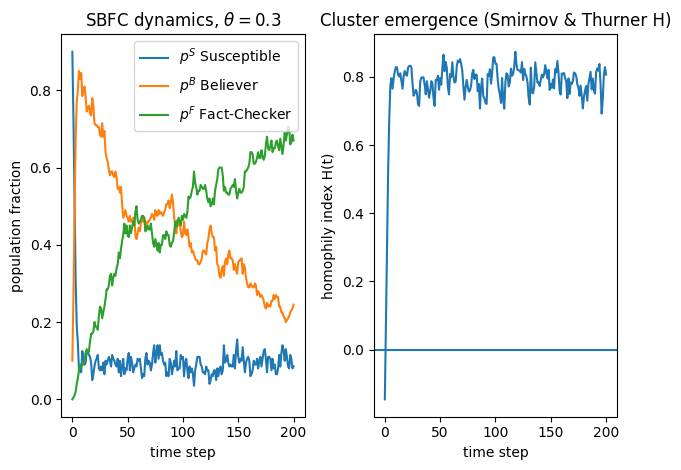

In [ ]:
# SBFC time-series (left) and homophily index H(t) (right).
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(df.index, df["pS"], label=r"$p^S$ Susceptible")
ax1.plot(df.index, df["pB"], label=r"$p^B$ Believer")
ax1.plot(df.index, df["pF"], label=r"$p^F$ Fact-Checker")
ax1.set_xlabel("time step")
ax1.set_ylabel("population fraction")
ax1.set_title(r"SBFC dynamics, $\theta=0.3$")
ax1.legend()

ax2.plot(df.index, df["H"])
ax2.set_xlabel("time step")
ax2.set_ylabel(r"homophily index H(t)")
ax2.set_title("Cluster emergence (Smirnov & Thurner H)")
ax2.axhline(0)

fig.tight_layout()
plt.show()

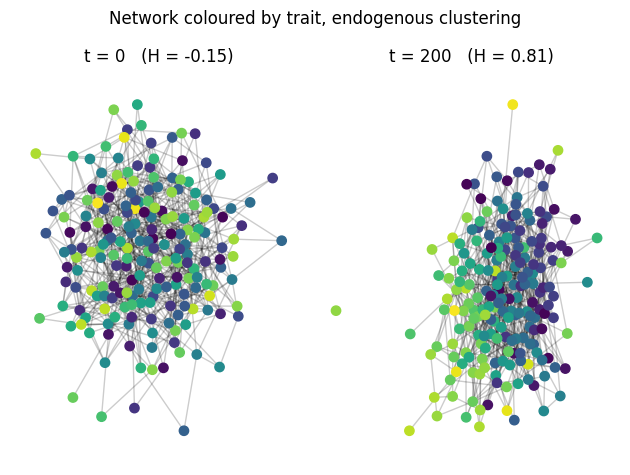

In [ ]:
# Network at t=0 vs t=T, nodes coloured by their static trait.
# As H(t) rises, similar-coloured nodes should group together.

def draw_trait_network(ax, graph, title):
    # spring layout pulls connected (= similar-trait) nodes together
    positions = nx.spring_layout(graph, seed=GLOBAL_SEED, k=0.3, iterations=80)

    # colour each node by its static trait
    node_colours = []
    for node in graph.nodes:
        node_colours.append(traits[node])

    nx.draw_networkx_edges(graph, positions, ax=ax, alpha=0.2)
    nx.draw_networkx_nodes(graph, positions, ax=ax,
                           node_size=45, vmin=0, vmax=1,
                           node_color=node_colours)
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 2)
draw_trait_network(axes[0], G0, f"t = 0   (H = {df['H'].iloc[0]:.2f})")
draw_trait_network(axes[1], GT, f"t = {T}   (H = {df['H'].iloc[-1]:.2f})")
fig.suptitle("Network coloured by trait, endogenous clustering")
fig.tight_layout()
plt.show()

### C: Interpretation of the diagnostic run

This diagnostic run uses intermediate homophily ($\theta = 0.3$) with the fact-checking probability set clearly below the Tambuscio eradication threshold ($p_{\text{verify}} = 0.02$ against the threshold value $\frac{2\alpha}{1-\alpha}\,p_{\text{forget}} \approx 0.043$).

The SBFC time series shows the fraction of Susceptibles $p^S$ dropping steeply within the first few steps and then stabilizing around $0.09$–$0.11$, which matches the mean-field prediction $p^S(\infty) = p_{\text{forget}}/(\beta + p_{\text{forget}}) \approx 0.09$ of Tambuscio et al. (2015, p. 980, Eq. 6). The Believer fraction $p^B$ rises sharply from the seeded carriers to around $0.85$, because the seeds start clustered in the high-trait region, benefit from the credibility advantage $\alpha$, and initially face no fact-checkers at all. Fact-checkers then gain ground steadily: by $t = 200$, $p^F \approx 0.67$ while $p^B \approx 0.25$. Crucially, the hoax does not die out: with $p_{\text{verify}}$ below the analytical threshold, the believer population settles at an endemic level, exactly as the mean-field theory predicts. Since $p^B$ is still drifting slightly downward at $t = 200$, the main experiments run longer ($T = 300$) and estimate $p^B(\infty)$ from the average of the final 20 steps.

The homophily index $H(t)$ starts near zero ($-0.15$, the random ER baseline), jumps to roughly $0.8$ within the first few steps, and then fluctuates around that plateau for the rest of the run. The selective rewiring therefore produces endogenous clusters of like-minded agents very quickly and maintains them, consistent with Smirnov and Thurner (2017).

The network plots at $t = 0$ versus $t = T$ (nodes coloured by trait) illustrate the same process: at $t = 200$ a visible sorting of light and dark nodes into different regions has emerged, although the spring layout of a dense graph blurs the separation. The jump in $H(t)$ from $-0.15$ to $0.81$ remains the more reliable, quantitative evidence of cluster emergence.

## D: Main experiment — sweep over $\theta$ (H1 and H3)

To answer our main research question, we sweep $\theta$ across its full range.
We run one model for each value in $\theta \in \{0.0, 0.1, \ldots, 1.0\}$, repeating
each value with 30 different random seeds so we can report averages and spread.
Everything else (the spreading parameters, network size, and topology) stays
the same across all runs.

The thing we record at the end of each run is $p^B(\infty)$, the fraction of
believers left in the population. We use the mean of the last 20 steps rather
than just the final step, to smooth out any leftover noise at equilibrium.

This directly tests:

- **H1**: if the curve slopes downward (lower $\theta$ → higher $p^B$), homophily
  amplifies misinformation, consistent with Törnberg (2018) who finds that
  echo-chamber structure boosts viral spread of complex contagions (p. 7, Fig. 1).
- **H3**: if the curve has a visible kink or flat region rather than being a
  straight line, the relationship is non-linear, also consistent with Törnberg
  (2018) who reports that virality peaks at intermediate polarization rather than
  at the maximum (p. 7, Fig. 1).

We run each model for $T = 300$ steps. Section C already showed that
$H(t)$ and $p^B$ both stabilise well before $t = 200$, so 300 is
a safe margin. We keep $N = 200$ agents throughout; Section F checks
whether the result changes on a different network type.

In [ ]:
# --- D: theta sweep parameters ---
THETA_VALUES     = np.round(np.linspace(0.0, 1.0, 11), 2)   # 0.0, 0.1, ..., 1.0
N_SEEDS          = 30      # independent replications per theta value
T_STEPS          = 300     # steps per run (confirmed sufficient in Section C)

# spreading parameters are fixed throughout D and E
BETA    = 0.5
ALPHA   = 0.3
P_VERIFY = 0.02   # way below the Tambuscio threshold (0.043)
P_FORGET = 0.05

# collect final pB for every (theta, seed) combination
records = []

for theta in tqdm(THETA_VALUES, desc="theta sweep"):
    for s in range(N_SEEDS):
        # each replicate gets a fully independent seed
        run_seed = GLOBAL_SEED + int(theta * 100) * 1000 + s
        model = HomophilyMisinfoModel(
            N=200, network="ER", avg_degree=6,
            theta=theta, beta=BETA, alpha=ALPHA,
            p_verify=P_VERIFY, p_forget=P_FORGET,
            seed_believer_frac=0.10, seed=run_seed
        )
        model.run_for(T_STEPS)
        df_run = model.datacollector.get_model_vars_dataframe()
        # use the mean of the last 20 steps as the steady-state estimate
        # (reduces noise from short-term fluctuations at equilibrium)
        pb_inf = df_run["pB"].iloc[-20:].mean()
        records.append({"theta": theta, "seed": s, "pB_inf": pb_inf})

sweep_df = pd.DataFrame(records)
print(sweep_df.groupby("theta")["pB_inf"].describe().round(4))

theta sweep:   0%|          | 0/11 [00:00<?, ?it/s]

       count    mean     std     min     25%     50%     75%     max
theta                                                               
0.0     30.0  0.1520  0.0713  0.0062  0.1004  0.1498  0.2148  0.2798
0.1     30.0  0.2274  0.0670  0.1035  0.1968  0.2226  0.2790  0.3512
0.2     30.0  0.2575  0.0934  0.0000  0.2141  0.2722  0.3182  0.3930
0.3     30.0  0.2743  0.0779  0.1015  0.2342  0.2742  0.3273  0.4172
0.4     30.0  0.2353  0.0828  0.0628  0.1741  0.2324  0.2936  0.3780
0.5     30.0  0.2468  0.0629  0.1018  0.2063  0.2591  0.2827  0.3958
0.6     30.0  0.2160  0.0648  0.0760  0.1862  0.2164  0.2596  0.3935
0.7     30.0  0.2535  0.0851  0.0885  0.1895  0.2445  0.3126  0.4178
0.8     30.0  0.2455  0.0849  0.0940  0.1668  0.2465  0.3080  0.4095
0.9     30.0  0.2560  0.0751  0.0355  0.2183  0.2604  0.3154  0.3985
1.0     30.0  0.2329  0.0742  0.0783  0.1890  0.2418  0.2782  0.3600


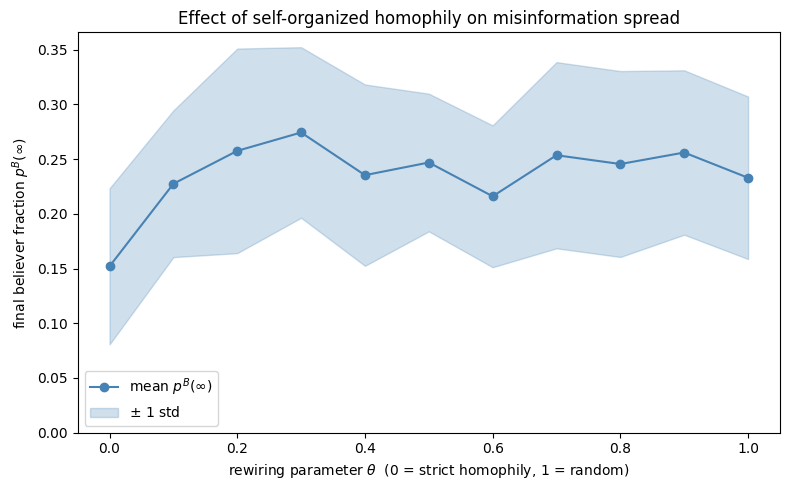

In [ ]:
# plot mean +- std of pB(inf) as a function of theta
summary = sweep_df.groupby("theta")["pB_inf"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary["theta"], summary["mean"], marker="o", color="steelblue",
        label=r"mean $p^B(\infty)$")
ax.fill_between(summary["theta"],
                summary["mean"] - summary["std"],
                summary["mean"] + summary["std"],
                alpha=0.25, color="steelblue", label=r"$\pm$ 1 std")
ax.set_xlabel(r"rewiring parameter $\theta$  (0 = strict homophily, 1 = random)")
ax.set_ylabel(r"final believer fraction $p^B(\infty)$")
ax.set_title(r"Effect of self-organized homophily on misinformation spread")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(bottom=0)
ax.legend()
fig.tight_layout()
plt.show()

### D: Interpretation

H1 is not supported; the data point in the opposite direction. Rather than rising as $\theta$ decreases, $p^B(\infty)$ is clearly *lowest* under strict homophily: the mean at $\theta = 0$ is $0.152$, it rises to a maximum of $0.274$ at $\theta = 0.3$, and then stays on a noisy plateau between roughly $0.22$ and $0.26$ up to $\theta = 1$. With 30 replications per condition (standard deviations around $0.06$–$0.09$, i.e. standard errors of the mean around $0.013$), the gap between $\theta = 0$ and the plateau is well outside the noise, so the suppression effect at strict homophily is a genuine feature of the model rather than sampling variation.

A plausible mechanism for this reversal of H1: under low $\theta$, believers cluster tightly through selective rewiring (Smirnov & Thurner 2017, p. 9), but this same clustering cuts them off from susceptibles. The hoax circulates within the high-trait cluster but cannot easily recruit new believers from the rest of the network. Once $\theta$ rises above roughly $0.3$, enough random rewiring keeps the network mixed and the hoax reaches its unconstrained endemic level, which is why the curve flattens.

This is also a meaningful difference from Törnberg (2018): his echo chambers are hard-coded into the network at $t = 0$ and are already full of believers, whereas our clusters form gradually through rewiring while spreading is already running. In a co-evolving system, the cluster boundary acts as a containment wall around the seeded believers instead of an incubation chamber.

H3 (non-linearity) receives at most weak support. There is a local maximum at $\theta = 0.3$ ($0.274$, compared to $0.233$ at $\theta = 1$), which superficially resembles Törnberg's (2018, p. 7, Fig. 1) finding that virality peaks at intermediate rather than maximum polarization. However, the differences along the plateau are small relative to the error bands, so the only robust non-linear feature is the initial rise from $\theta = 0$ to $\theta \approx 0.3$ followed by saturation, not a clear interior peak.

## E: Secondary experiment — threshold-shift test (H2)

Tambuscio et al. (2015) derived an analytical eradication threshold from a
mean-field approximation (p. 980, Eq. 9; Appendix A, pp. 981–982):

$$p_{\text{verify}}^* = \frac{2\alpha}{1-\alpha}\, p_{\text{forget}}$$

If $p_{\text{verify}}$ is at or above this value, the hoax should die out
completely ($p^B(\infty) = 0$). The key assumption behind this derivation is
that the network is static and well-mixed, every node is equally reachable.

H2 says that homophily breaks this assumption: believers end up clustered
together, shielded from fact-checkers by the rewiring mechanism from Smirnov &
Thurner (2017). So more fact-checking effort should be needed to actually
eradicate the hoax when $\theta$ is low.

To test this, we keep $\alpha$ and $p_{\text{forget}}$ fixed and sweep
$p_{\text{verify}}$ from below to above the analytical threshold. We only do
this for the two extreme values of $\theta$:

- $\theta = 0$: strict homophily, strongest possible clustering
- $\theta = 1$: no homophilic preference, so no endogenous clustering forms;
  this is the closest approximation to the well-mixed network assumed in the
  analytical derivation

We run 30 seeds per combination and look at the mean $p^B(\infty)$. The
empirical eradication point is the lowest $p_{\text{verify}}$ value where the
mean drops to or below $\varepsilon = 0.01$.

If H2 holds, the $\theta = 0$ curve should sit higher (more believers survive)
and its eradication point should be shifted to the right of the $\theta = 1$
curve and of the analytical threshold.

In [ ]:
# --- E: threshold-shift sweep parameters ---
# analytical threshold given our alpha and p_forget
P_VERIFY_ANALYTICAL = 2 * ALPHA / (1 - ALPHA) * P_FORGET
print(f"Analytical Tambuscio threshold: p_verify* = {P_VERIFY_ANALYTICAL:.4f}")

# sweep p_verify from well below to well above the analytical threshold
# 13 points so there is a value on each side of the threshold (~0.043)
P_VERIFY_VALUES = np.round(np.linspace(0.01, 0.12, 13), 4)
THETA_EXTREME   = [0.0, 1.0]   # strict homophily vs. random rewiring
ERADICATION_TOL = 0.01         # pB(inf) <= this counts as eradicated

thresh_records = []

for theta in THETA_EXTREME:
    for p_v in tqdm(P_VERIFY_VALUES, desc=f"theta={theta}"):
        for s in range(N_SEEDS):
            run_seed = GLOBAL_SEED + int(theta * 100) * 100000 + int(p_v * 10000) + s
            model = HomophilyMisinfoModel(
                N=200, network="ER", avg_degree=6,
                theta=theta, beta=BETA, alpha=ALPHA,
                p_verify=p_v, p_forget=P_FORGET,
                seed_believer_frac=0.10, seed=run_seed
            )
            model.run_for(T_STEPS)
            df_run = model.datacollector.get_model_vars_dataframe()
            pb_inf = df_run["pB"].iloc[-20:].mean()
            thresh_records.append({
                "theta": theta, "p_verify": p_v,
                "seed": s, "pB_inf": pb_inf
            })

thresh_df = pd.DataFrame(thresh_records)

Analytical Tambuscio threshold: p_verify* = 0.0429


theta=0.0:   0%|          | 0/13 [00:00<?, ?it/s]

theta=1.0:   0%|          | 0/13 [00:00<?, ?it/s]

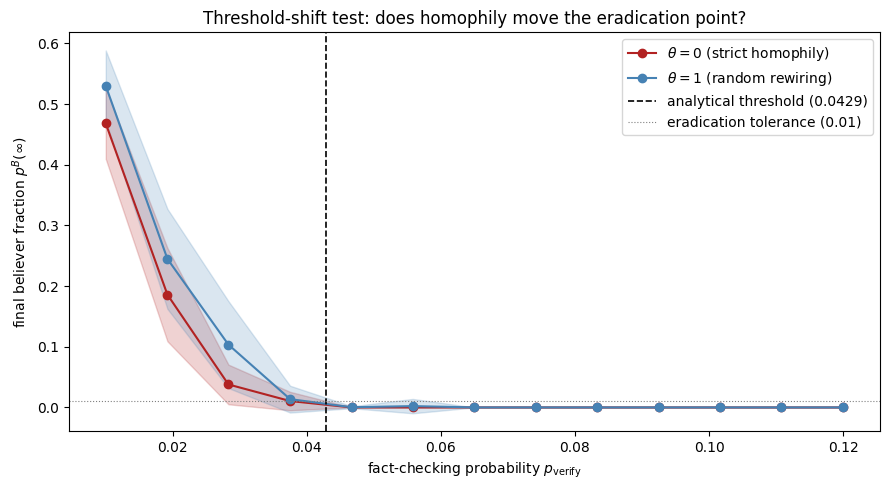

Empirical eradication points (first p_verify with mean pB <= tolerance):
  theta=0.0: p_verify = 0.0467
  theta=1.0: p_verify = 0.0467


In [ ]:
# --- E: plot pB(inf) vs p_verify for theta=0 and theta=1 ---
fig, ax = plt.subplots(figsize=(9, 5))

colors = {0.0: "firebrick", 1.0: "steelblue"}
labels = {0.0: r"$\theta = 0$ (strict homophily)",
          1.0: r"$\theta = 1$ (random rewiring)"}

for theta in THETA_EXTREME:
    sub = thresh_df[thresh_df["theta"] == theta]
    agg = sub.groupby("p_verify")["pB_inf"].agg(["mean", "std"]).reset_index()
    ax.plot(agg["p_verify"], agg["mean"], marker="o",
            color=colors[theta], label=labels[theta])
    ax.fill_between(agg["p_verify"],
                    agg["mean"] - agg["std"],
                    agg["mean"] + agg["std"],
                    alpha=0.2, color=colors[theta])

# mark the analytical threshold and the eradication tolerance line
ax.axvline(P_VERIFY_ANALYTICAL, lw=1.2, ls="--", color="black",
           label=f"analytical threshold ({P_VERIFY_ANALYTICAL:.4f})")
ax.axhline(ERADICATION_TOL, lw=0.8, ls=":", color="gray",
           label=f"eradication tolerance ({ERADICATION_TOL})")

ax.set_xlabel(r"fact-checking probability $p_{\mathrm{verify}}$")
ax.set_ylabel(r"final believer fraction $p^B(\infty)$")
ax.set_title("Threshold-shift test: does homophily move the eradication point?")
ax.legend()
fig.tight_layout()
plt.show()

# print the empirical eradication point for each theta
print("Empirical eradication points (first p_verify with mean pB <= tolerance):")
for theta in THETA_EXTREME:
    sub = thresh_df[thresh_df["theta"] == theta]
    agg = sub.groupby("p_verify")["pB_inf"].mean()
    eradicated = agg[agg <= ERADICATION_TOL]
    if len(eradicated):
        print(f"  theta={theta}: p_verify = {eradicated.index[0]:.4f}")
    else:
        print(f"  theta={theta}: hoax not eradicated within the swept range")

### E: Interpretation

H2 is not supported. The empirical eradication point is identical for both extremes: at $\theta = 0$ and at $\theta = 1$ the mean $p^B(\infty)$ first drops below the eradication tolerance at $p_{\text{verify}} = 0.0467$. Self-organized homophily does not shift the eradication threshold in our model. Both curves converge already slightly below the analytical threshold and lie on top of each other for all larger $p_{\text{verify}}$ values.

The empirical point sits marginally above the analytical value of $0.0429$ (Tambuscio et al. 2015, p. 980, Eq. 9). This small offset is expected from our implementation: the Believer update draws the forgetting and verification events sequentially, so the effective verification probability is $(1 - p_{\text{forget}}) \cdot p_{\text{verify}}$ rather than $p_{\text{verify}}$, which shifts the predicted threshold to $\approx 0.045$, between our two grid points $0.0375$ and $0.0467$. Given this correction, the agreement with the mean-field prediction is close, suggesting that the implementation faithfully reproduces the Tambuscio et al. (2015) dynamics and that using $N = 200$ rather than their $N = 1000$ (p. 979) does not meaningfully move the threshold.

Below the threshold ($p_{\text{verify}} = 0.01$–$0.03$) a consistent gap is visible: the $\theta = 0$ curve lies below $\theta = 1$ (e.g. $0.47$ vs. $0.53$ at $p_{\text{verify}} = 0.01$), meaning strict homophily produces *fewer* believers even when fact-checking is rare. This mirrors the suppression effect from Section D; the gap closes as $p_{\text{verify}}$ approaches the threshold and both populations collapse.

Together with Section D, this points toward a consistent picture: self-organized homophily in our model acts as a containment mechanism for the hoax rather than an amplifier, and it changes how *many* believers survive below the threshold, but not *where* the threshold lies. The policy implication is that fact-checking recommendations based on the original Tambuscio et al. (2015) threshold do not need to be adjusted upward for homophilic networks, at least under this dynamic rewiring model.

## F: Robustness checks

The results from D and E could in principle just reflect our specific modelling
choices rather than the mechanism we care about. We run two checks to see if the
main findings hold under different conditions.

**F1: Network topology: ER vs. BA.**
All of D and E used an Erdős–Rényi (ER) base graph, where degrees are roughly
equal across nodes. Tambuscio et al. (2015) already compared ER and
Barabási–Albert (BA) networks and found that the two behave similarly for their
base parameters (p. 979, Fig. 2). BA graphs have hubs, a small number of
highly connected nodes, which can act as super-spreaders or efficient
fact-checking broadcasters (Mazzoli et al. 2018, Section 1, p. 2). If the
$\theta$ effect we find in D still points in the same direction on a BA graph,
we can be more confident it is not just an ER artefact.

We use `m_ba=3`, which gives an average degree of about 6 (the same as the
`avg_degree=6` setting in Section D).

**F2: Initial believer fraction.**
In D we seeded the top 10% of the trait distribution as initial believers.
This deliberately links the starting condition to the homophily mechanism:
under low $\theta$, these high-trait agents cluster together, giving the hoax
a concentrated starting point. We now test 5% and 20% seeds to check whether
the direction of the effect holds regardless of how large the initial outbreak
is. A very small seed (5%) may die out by chance before any clustering has
formed; a large seed (20%) gives the hoax such a head start that clustering
might matter less.

In [ ]:
# --- F1: topology robustness — repeat theta sweep on BA graph ---
ba_records = []

for theta in tqdm(THETA_VALUES, desc="BA sweep"):
    for s in range(N_SEEDS):
        run_seed = GLOBAL_SEED + 9000000 + int(theta * 100) * 1000 + s
        model = HomophilyMisinfoModel(
            N=200, network="BA", m_ba=3,   # avg degree ~6, matching ER sweep
            theta=theta, beta=BETA, alpha=ALPHA,
            p_verify=P_VERIFY, p_forget=P_FORGET,
            seed_believer_frac=0.10, seed=run_seed
        )
        model.run_for(T_STEPS)
        df_run = model.datacollector.get_model_vars_dataframe()
        pb_inf = df_run["pB"].iloc[-20:].mean()
        ba_records.append({"theta": theta, "seed": s, "pB_inf": pb_inf})

ba_df = pd.DataFrame(ba_records)

BA sweep:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
# --- F2: seed-fraction robustness ---
SEED_FRACS = [0.05, 0.20]
frac_records = []

for frac in SEED_FRACS:
    for theta in tqdm(THETA_VALUES, desc=f"seed_frac={frac}"):
        for s in range(N_SEEDS):
            run_seed = GLOBAL_SEED + int(frac * 1000) * 10000000 + int(theta * 100) * 1000 + s
            model = HomophilyMisinfoModel(
                N=200, network="ER", avg_degree=6,
                theta=theta, beta=BETA, alpha=ALPHA,
                p_verify=P_VERIFY, p_forget=P_FORGET,
                seed_believer_frac=frac, seed=run_seed
            )
            model.run_for(T_STEPS)
            df_run = model.datacollector.get_model_vars_dataframe()
            pb_inf = df_run["pB"].iloc[-20:].mean()
            frac_records.append({
                "seed_frac": frac, "theta": theta,
                "seed": s, "pB_inf": pb_inf
            })

frac_df = pd.DataFrame(frac_records)

seed_frac=0.05:   0%|          | 0/11 [00:00<?, ?it/s]

seed_frac=0.2:   0%|          | 0/11 [00:00<?, ?it/s]

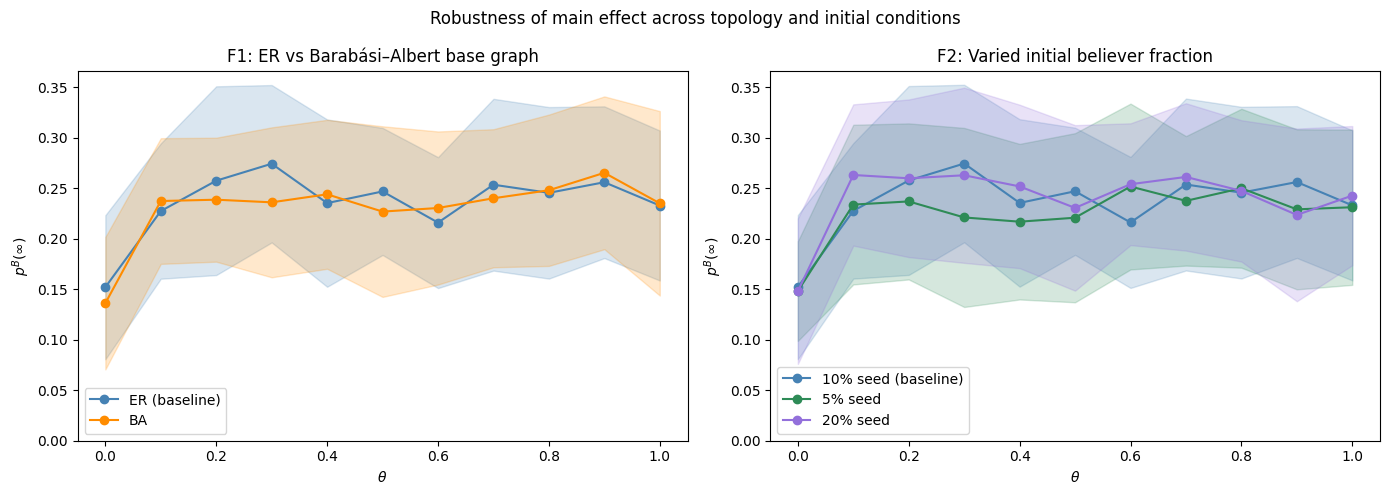

In [ ]:
# --- F: combined robustness plot (2 panels) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# F1: ER vs BA
er_sum = sweep_df.groupby("theta")["pB_inf"].agg(["mean", "std"]).reset_index()
ba_sum = ba_df.groupby("theta")["pB_inf"].agg(["mean", "std"]).reset_index()

for agg, label, color in [(er_sum, "ER (baseline)", "steelblue"),
                           (ba_sum, "BA", "darkorange")]:
    ax1.plot(agg["theta"], agg["mean"], marker="o", color=color, label=label)
    ax1.fill_between(agg["theta"],
                     agg["mean"] - agg["std"],
                     agg["mean"] + agg["std"],
                     alpha=0.2, color=color)
ax1.set_xlabel(r"$\theta$"); ax1.set_ylabel(r"$p^B(\infty)$")
ax1.set_xlim(-0.05, 1.05); ax1.set_ylim(bottom=0)
ax1.set_title("F1: ER vs Barabási–Albert base graph"); ax1.legend()

# F2: seed fraction
colors_frac = {0.05: "seagreen", 0.10: "steelblue", 0.20: "mediumpurple"}
labels_frac = {0.05: "5% seed", 0.10: "10% seed (baseline)", 0.20: "20% seed"}

# include the 10% baseline from sweep_df
for df_src, frac in [(sweep_df, 0.10)] + [(frac_df[frac_df["seed_frac"] == f], f)
                                           for f in SEED_FRACS]:
    agg = df_src.groupby("theta")["pB_inf"].agg(["mean", "std"]).reset_index()
    ax2.plot(agg["theta"], agg["mean"], marker="o",
             color=colors_frac[frac], label=labels_frac[frac])
    ax2.fill_between(agg["theta"],
                     agg["mean"] - agg["std"],
                     agg["mean"] + agg["std"],
                     alpha=0.2, color=colors_frac[frac])
ax2.set_xlabel(r"$\theta$"); ax2.set_ylabel(r"$p^B(\infty)$")
ax2.set_xlim(-0.05, 1.05); ax2.set_ylim(bottom=0)
ax2.set_title("F2: Varied initial believer fraction"); ax2.legend()

fig.suptitle("Robustness of main effect across topology and initial conditions")
fig.tight_layout()
plt.show()

### F: Interpretation

**F1: Topology.** The BA curve and the ER baseline are nearly indistinguishable: both show the dip at $\theta = 0$ (means of $0.136$ for BA vs. $0.152$ for ER), the rise up to $\theta \approx 0.2$–$0.3$, and the same noisy plateau around $0.22$–$0.27$ afterwards, with heavily overlapping error bands. The suppression of the hoax under strict homophily, and the saturation at higher $\theta$, are therefore not artefacts of the Erdős–Rényi topology; the same co-evolutionary mechanism dominates on a scale-free base graph (cf. Tambuscio et al. 2015, p. 979, who likewise find closely matching dynamics on BA and ER networks when $R_0 \gg 1$).

**F2: Seed fraction.** All three curves (5%, 10%, 20% initial believers) overlap within their error bands and reproduce the same shape: lowest $p^B(\infty)$ at $\theta = 0$, then a plateau. There is no consistent ordering by seed size on the plateau, which is expected, since the endemic equilibrium of the SBFC process is determined by the rate parameters rather than the initial condition. The containment effect at strict homophily holds regardless of how many believers we start with.

**Overall robustness.** Both checks confirm the pattern from Sections D and E: a moderate but reliable suppression of the hoax under strict homophily ($\theta = 0$) and no amplification anywhere in the $\theta$ range, across two topologies and three initial believer fractions. The run-to-run variance remains substantial in all conditions (individual runs range roughly from $0.05$ to $0.4$), reflecting the path-dependence of a stochastic process on a small network ($N = 200$); 30 seeds are sufficient to pin down the $\theta = 0$ effect, but finer differences along the plateau, such as the putative peak at $\theta = 0.3$, would require considerably more replications to resolve.